In [1]:
import pandas as pd

ridership = pd.read_csv('Datasets/ridership.csv')
ridership.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092474 entries, 0 to 1092473
Data columns (total 4 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   route    1092474 non-null  object
 1   date     1092474 non-null  object
 2   daytype  1092474 non-null  object
 3   rides    1092474 non-null  object
dtypes: object(4)
memory usage: 33.3+ MB


/var/folders/y1/1zf0l7g530dd_mqbfll_qkhh0000gn/T/ipykernel_41506/4274688381.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ridership = pd.read_csv('Datasets/ridership.csv')


In [2]:
ridership.head()

,route,date,daytype,rides
0,1,01/02/2001,W,"5,813"
1,1,01/03/2001,W,"6,809"
2,1,01/04/2001,W,"6,907"
3,1,01/05/2001,W,"6,154"
4,1,01/08/2001,W,"6,126"


In [3]:
ridership.sort_values(by='rides', ascending=False)

,route,date,daytype,rides
36839,106,07/25/2017,W,999
1045002,96,09/13/2006,W,999
352216,206,04/14/2011,W,999
82779,115,11/28/2025,W,999
896412,81W,02/17/2007,A,999
...,...,...,...,...
268360,169,12/31/2001,W,0
1059009,992,05/12/2020,W,0
1059016,992,06/16/2020,W,0
31603,106,02/09/2003,U,0


In [4]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['rides'] = ridership['rides'].str.replace(',','').astype(int)
ridership['route'] = ridership['route'].astype(str)

In [5]:
ridership = ridership[ridership.date >= '2025-01-01'].reset_index(drop=True)
ridership.route.value_counts()

route
49     334
4      334
52     334
51     334
50     334
      ... 
19     136
N5     134
130    112
10     102
128      8
Name: count, Length: 129, dtype: int64

In [6]:
ridership_by_date = pd.DataFrame(ridership.groupby(['route'])['rides'].mean().reset_index())
ridership_by_date

,route,rides
0,1,1100.600858
1,10,414.470588
2,100,364.060086
3,1001,1004.461078
4,103,1142.116766
...,...,...
124,J14,6182.604790
125,N5,111.350746
126,X4,2483.678112
127,X49,4534.639485


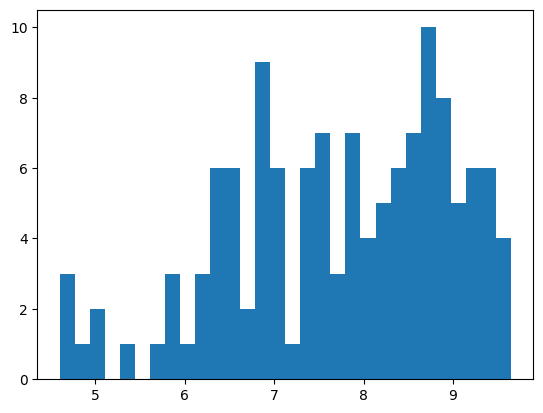

In [24]:
import matplotlib.pyplot as plt
import numpy as np
plt.show()

ridership_by_date['log_ridership'] = np.log1p(ridership_by_date.rides)

plt.hist(ridership_by_date.log_ridership, bins=30)
plt.show()

In [25]:
ridership_by_date.to_csv('metrics_results/ridership_results.csv')

In [8]:
metrics = pd.read_csv('metrics_results/mar1_full_results.csv')

In [9]:
metrics['bus_trust_score'] = (
    0.45 * metrics['p_otp'] +
    0.25 * metrics['p_severity'] +
    0.20 * metrics['p_reliability'] +
    0.10 * metrics['p_ghost']
).round(1)

In [10]:
metrics = metrics[['route_id', 'bus_trust_score']].sort_values(by='bus_trust_score')

In [11]:
ridership_by_date

,route,rides
0,1,1100.600858
1,10,414.470588
2,100,364.060086
3,1001,1004.461078
4,103,1142.116766
...,...,...
124,J14,6182.604790
125,N5,111.350746
126,X4,2483.678112
127,X49,4534.639485


In [12]:
ridership_by_date['ridership_score'] = (ridership_by_date.rides - ridership_by_date.rides.min()) / (ridership_by_date.rides.max() - ridership_by_date.rides.min())

In [13]:
metrics = metrics.merge(ridership_by_date, right_on='route', left_on='route_id', how='left')

In [14]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   route_id         123 non-null    object 
 1   bus_trust_score  123 non-null    float64
 2   route            123 non-null    object 
 3   rides            123 non-null    float64
 4   ridership_score  123 non-null    float64
dtypes: float64(3), object(2)
memory usage: 4.9+ KB


In [15]:
metrics['route_score'] = metrics.bus_trust_score + metrics.ridership_score

In [16]:
metrics.head()

,route_id,bus_trust_score,route,rides,ridership_score,route_score
0,171,53.9,171,602.758007,0.032795,53.932795
1,N5,54.7,N5,111.350746,0.000803,54.700803
2,62,55.1,62,6658.338323,0.427034,55.527034
3,201,65.9,201,1139.989324,0.067771,65.967771
4,169,66.5,169,99.014493,0.000000,66.500000
